# Analyze Latent Space Rollout Error

This notebook loads the per-timestep latent space error data generated by `evaluate_latent_space.py` and uses the reusable plotting function from `mhd_surrogate_core` to visualize the stability of the learned linear dynamics.

### 1. Setup and Imports

In [7]:
from pathlib import Path

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_latent_rollout_error

### 2. Specify Error File Path and Plot

**Action Required:** Change the `error_file_path` variable below to point to the specific `latent_rollout_error.npz` file you want to analyze. This file is generated by the `evaluate_latent_space.py` script.

2025-07-06 16:04:38,669 - INFO - Loading latent rollout error from /raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/latent_rollout_error_train_val.npz...


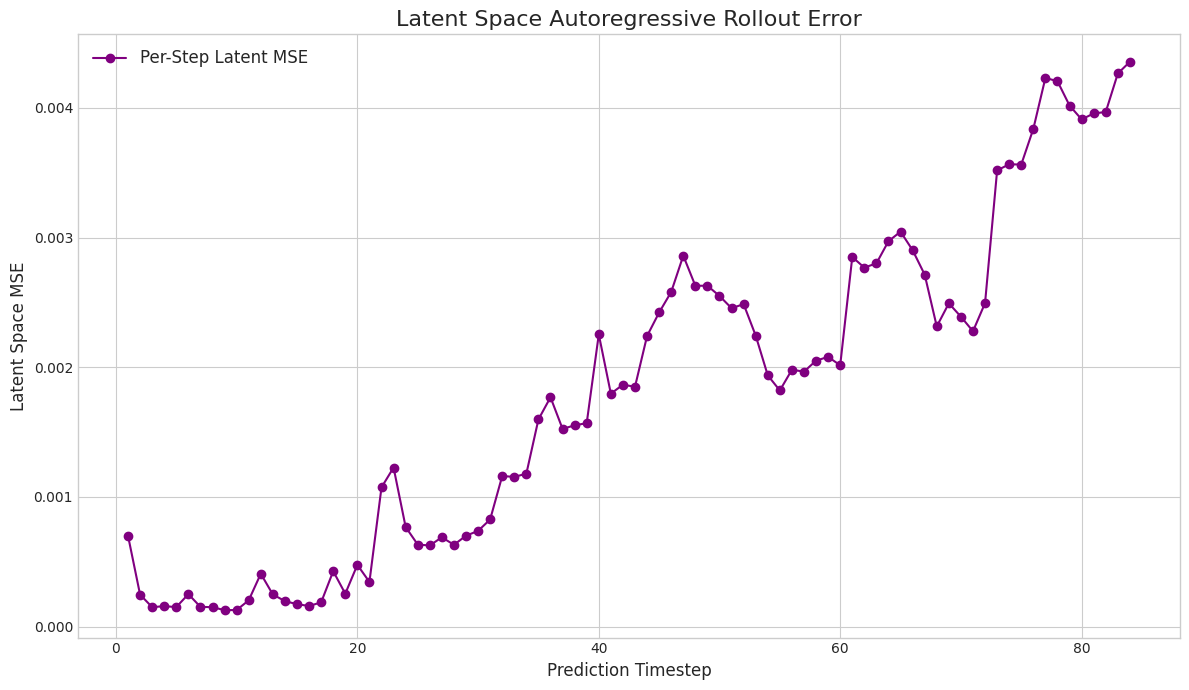

In [8]:
# Example path - update this to your specific run's output.
# This path matches the structure created by the run_sweep.sh script.
error_file_path = Path("/raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/latent_rollout_error_train_val.npz")

# Call the plotting function
if error_file_path.exists():
    plot_latent_rollout_error(error_file_path)
else:
    print(f"ERROR: Error file not found at {error_file_path}")
    print("Please run evaluate_latent_space.py first and/or update the path.")

### Analysis

This plot provides a pure assessment of the learned linear operator, isolated from the performance of the decoder.

- **A Good Koopman Operator:** The error should start at zero and remain very low and flat. This indicates that the learned linear operator `K` is a good approximation of the true dynamics in the latent space created by the encoder.
- **A Poor Koopman Operator:** The error will grow over time. This shows that even if the encoder finds a good representation, the linear operator itself is not correctly capturing the evolution of the system, leading to diverging predictions in the latent space.